In [29]:
# ============================================================
# NOTEBOOK 1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -----------------------------
# Plot settings
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# -----------------------------
# Find project root automatically
# -----------------------------
current_dir = Path.cwd()
project_root = None

for folder in [current_dir] + list(current_dir.parents):
    if (folder / "data").exists():
        project_root = folder
        break

if project_root is None:
    raise FileNotFoundError(
        "Could not find the project root folder containing 'data'.\n"
        f"Current working directory: {current_dir}"
    )

# -----------------------------
# Dataset path
# -----------------------------
DATA_FILE = project_root / "data" / "health_nutrition_disease_dataset_12000.xlsx"

# Fallback: your exact absolute path
if not DATA_FILE.exists():
    DATA_FILE = Path(
        r"D:\iit\DSGP\NutriScanner\health-risk-recommendations\data\health_nutrition_disease_dataset_12000.xlsx"
    )

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found.\nChecked path: {DATA_FILE}"
    )

# -----------------------------
# Useful folders
# -----------------------------
PLOT_DIR = project_root / "plots"
REPORT_DIR = project_root / "reports"
MODEL_DIR = project_root / "models"

PLOT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# -----------------------------
# Load dataset
# -----------------------------
print("Current working directory:", current_dir)
print("Project root:", project_root)
print("Dataset path:", DATA_FILE)
print("File exists:", DATA_FILE.exists())

df = pd.read_excel(DATA_FILE)

print("\nDataset loaded successfully")
print("Shape:", df.shape)

df.head()


Current working directory: D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks
Project root: D:\iit\DSGP\NutriScanner\health-risk-recommendations\research\NoteBooks
Dataset path: D:\iit\DSGP\NutriScanner\health-risk-recommendations\data\health_nutrition_disease_dataset_12000.xlsx
File exists: True

Dataset loaded successfully
Shape: (12000, 26)


,Age,Gender,BMI,Daily_Calories_kcal,Carbohydrates_g,Protein_g,Total_Fat_g,Saturated_Fat_g,Trans_Fat_g,Total_Sugar_g,...,Vitamin_D_IU,Vitamin_B12_mcg,Physical_Activity_min,Water_Intake_L,Diabetes_Risk,Hypertension_Risk,Heart_Disease_Risk,Obesity_Risk,Anemia_Risk,Kidney_Disease_Risk
0,65,Female,31.9,2723,256,90,58,68,3.74,85,...,861,4.21,78,2.64,High,High,Low,Low,Low,Low
1,22,Male,40.7,2315,311,131,138,24,4.43,79,...,348,1.32,77,1.04,High,Low,Low,Low,Low,High
2,43,Female,20.8,2519,206,201,166,20,2.67,206,...,199,2.16,163,2.17,Low,Low,Low,Low,Low,Low
3,72,Female,19.6,3536,228,71,52,48,2.79,5,...,1001,3.61,191,3.85,Low,Low,Low,Low,Low,Low
4,21,Female,26.2,2285,257,96,45,57,4.17,54,...,19,2.66,89,3.48,Low,Low,Low,Low,Low,Low


In [30]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel(DATA_FILE)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f" Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\n Columns ({len(df.columns)}):")

for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col} ({df[col].dtype})")

DATASET OVERVIEW
 Shape: 12000 rows × 26 columns
 Memory Usage: 6081.3 KB

 Columns (26):
    1. Age (int64)
    2. Gender (object)
    3. BMI (float64)
    4. Daily_Calories_kcal (int64)
    5. Carbohydrates_g (int64)
    6. Protein_g (int64)
    7. Total_Fat_g (int64)
    8. Saturated_Fat_g (int64)
    9. Trans_Fat_g (float64)
   10. Total_Sugar_g (int64)
   11. Added_Sugar_g (int64)
   12. Fiber_g (int64)
   13. Sodium_mg (int64)
   14. Potassium_mg (int64)
   15. Calcium_mg (int64)
   16. Iron_mg (float64)
   17. Vitamin_D_IU (int64)
   18. Vitamin_B12_mcg (float64)
   19. Physical_Activity_min (int64)
   20. Water_Intake_L (float64)
   21. Diabetes_Risk (object)
   22. Hypertension_Risk (object)
   23. Heart_Disease_Risk (object)
   24. Obesity_Risk (object)
   25. Anemia_Risk (object)
   26. Kidney_Disease_Risk (object)


In [31]:
# ============================================================
# FIRST LOOK AT DATA
# ============================================================

print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()

FIRST 5 ROWS


,Age,Gender,BMI,Daily_Calories_kcal,Carbohydrates_g,Protein_g,Total_Fat_g,Saturated_Fat_g,Trans_Fat_g,Total_Sugar_g,...,Vitamin_D_IU,Vitamin_B12_mcg,Physical_Activity_min,Water_Intake_L,Diabetes_Risk,Hypertension_Risk,Heart_Disease_Risk,Obesity_Risk,Anemia_Risk,Kidney_Disease_Risk
0,65,Female,31.9,2723,256,90,58,68,3.74,85,...,861,4.21,78,2.64,High,High,Low,Low,Low,Low
1,22,Male,40.7,2315,311,131,138,24,4.43,79,...,348,1.32,77,1.04,High,Low,Low,Low,Low,High
2,43,Female,20.8,2519,206,201,166,20,2.67,206,...,199,2.16,163,2.17,Low,Low,Low,Low,Low,Low
3,72,Female,19.6,3536,228,71,52,48,2.79,5,...,1001,3.61,191,3.85,Low,Low,Low,Low,Low,Low
4,21,Female,26.2,2285,257,96,45,57,4.17,54,...,19,2.66,89,3.48,Low,Low,Low,Low,Low,Low


In [32]:

print("=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
df.tail()

LAST 5 ROWS


,Age,Gender,BMI,Daily_Calories_kcal,Carbohydrates_g,Protein_g,Total_Fat_g,Saturated_Fat_g,Trans_Fat_g,Total_Sugar_g,...,Vitamin_D_IU,Vitamin_B12_mcg,Physical_Activity_min,Water_Intake_L,Diabetes_Risk,Hypertension_Risk,Heart_Disease_Risk,Obesity_Risk,Anemia_Risk,Kidney_Disease_Risk
11995,57,Male,24.9,2073,126,101,54,11,2.07,65,...,1050,2.45,117,4.52,Low,Low,Low,Low,Low,Low
11996,22,Female,36.6,1616,242,121,44,34,0.93,56,...,29,4.39,76,0.56,Low,Low,Low,Low,Low,High
11997,71,Male,28.1,3514,262,78,139,63,1.68,154,...,495,5.06,28,2.29,High,High,High,Low,Low,Low
11998,58,Male,17.4,3604,262,91,154,41,2.73,133,...,176,3.61,131,3.93,Low,Low,Low,Low,Low,Low
11999,30,Male,29.4,1874,160,138,73,39,3.06,44,...,791,0.64,159,4.04,Low,High,Low,Low,Low,Low


In [33]:
# ============================================================
# DATA TYPES & INFO
# ============================================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("DETAILED INFO")
print("=" * 60)
df.info()

DATA TYPES
Age                        int64
Gender                    object
BMI                      float64
Daily_Calories_kcal        int64
Carbohydrates_g            int64
Protein_g                  int64
Total_Fat_g                int64
Saturated_Fat_g            int64
Trans_Fat_g              float64
Total_Sugar_g              int64
Added_Sugar_g              int64
Fiber_g                    int64
Sodium_mg                  int64
Potassium_mg               int64
Calcium_mg                 int64
Iron_mg                  float64
Vitamin_D_IU               int64
Vitamin_B12_mcg          float64
Physical_Activity_min      int64
Water_Intake_L           float64
Diabetes_Risk             object
Hypertension_Risk         object
Heart_Disease_Risk        object
Obesity_Risk              object
Anemia_Risk               object
Kidney_Disease_Risk       object
dtype: object

DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 col

MISSING VALUES
 NO MISSING VALUES FOUND! Dataset is complete.


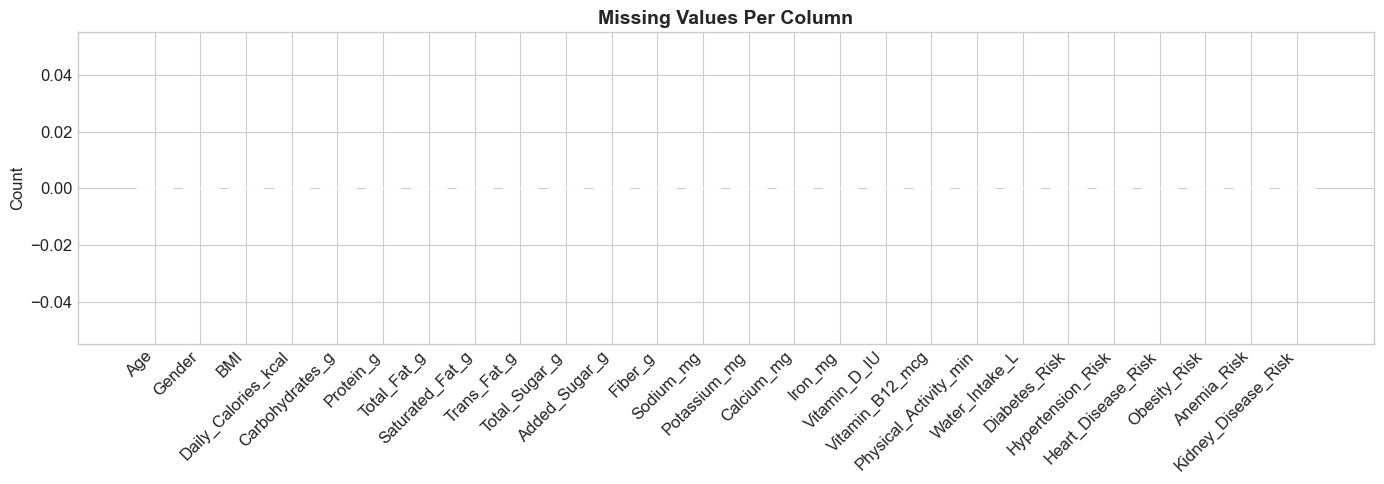

 Plot saved to plots/missing_values.png


In [34]:
# ============================================================
# MISSING VALUES ANALYSIS
# ============================================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing Count", ascending=False)

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

if missing.sum() == 0:
    print(" NO MISSING VALUES FOUND! Dataset is complete.")
else:
    print(" Missing values detected:")
    print(missing_df[missing_df["Missing Count"] > 0])

# Visualize missing values
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#2ecc71" if x == 0 else "#e74c3c" for x in missing.values]
ax.bar(range(len(missing)), missing.values, color=colors)
ax.set_xticks(range(len(missing)))
ax.set_xticklabels(missing.index, rotation=45, ha="right")
ax.set_title("Missing Values Per Column", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "missing_values.png"), dpi=150, bbox_inches="tight")
plt.show()
print(" Plot saved to plots/missing_values.png")

In [35]:
# ============================================================
# DUPLICATE ROWS ANALYSIS
# ============================================================

duplicates = df.duplicated().sum()
print("=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)

if duplicates == 0:
    print(f" No duplicate rows found!")
else:
    print(f" Found {duplicates} duplicate rows ({duplicates/len(df)*100:.2f}%)")
    print("Removing duplicates...")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f" After removal: {df.shape[0]} rows")

DUPLICATE ANALYSIS
 No duplicate rows found!


In [ ]:
# ============================================================
# STATISTICAL SUMMARY - NUMERICAL COLUMNS
# ============================================================

print("=" * 60)
print("DESCRIPTIVE STATISTICS - NUMERICAL")
print("=" * 60)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n Numerical columns ({len(numerical_cols)}): {numerical_cols}\n")

stats_df = df[numerical_cols].describe().T
stats_df["range"] = stats_df["max"] - stats_df["min"]
stats_df["iqr"] = stats_df["75%"] - stats_df["25%"]
stats_df["skewness"] = df[numerical_cols].skew()
stats_df["kurtosis"] = df[numerical_cols].kurtosis()

stats_df.round(2)

In [22]:
# ============================================================
# STATISTICAL SUMMARY - CATEGORICAL COLUMNS
# ============================================================

print("=" * 60)
print("CATEGORICAL COLUMNS ANALYSIS")
print("=" * 60)

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"\n Categorical columns ({len(categorical_cols)}): {categorical_cols}\n")

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

CATEGORICAL COLUMNS ANALYSIS

📋 Categorical columns (7): ['Gender', 'Diabetes_Risk', 'Hypertension_Risk', 'Heart_Disease_Risk', 'Obesity_Risk', 'Anemia_Risk', 'Kidney_Disease_Risk']


--- Gender ---
Gender
Female    6031
Male      5969
Name: count, dtype: int64
Unique values: 2

--- Diabetes_Risk ---
Diabetes_Risk
Low     8575
High    3425
Name: count, dtype: int64
Unique values: 2

--- Hypertension_Risk ---
Hypertension_Risk
Low     9218
High    2782
Name: count, dtype: int64
Unique values: 2

--- Heart_Disease_Risk ---
Heart_Disease_Risk
Low     10933
High     1067
Name: count, dtype: int64
Unique values: 2

--- Obesity_Risk ---
Obesity_Risk
Low     10157
High     1843
Name: count, dtype: int64
Unique values: 2

--- Anemia_Risk ---
Anemia_Risk
Low     11380
High      620
Name: count, dtype: int64
Unique values: 2

--- Kidney_Disease_Risk ---
Kidney_Disease_Risk
Low     10689
High     1311
Name: count, dtype: int64
Unique values: 2


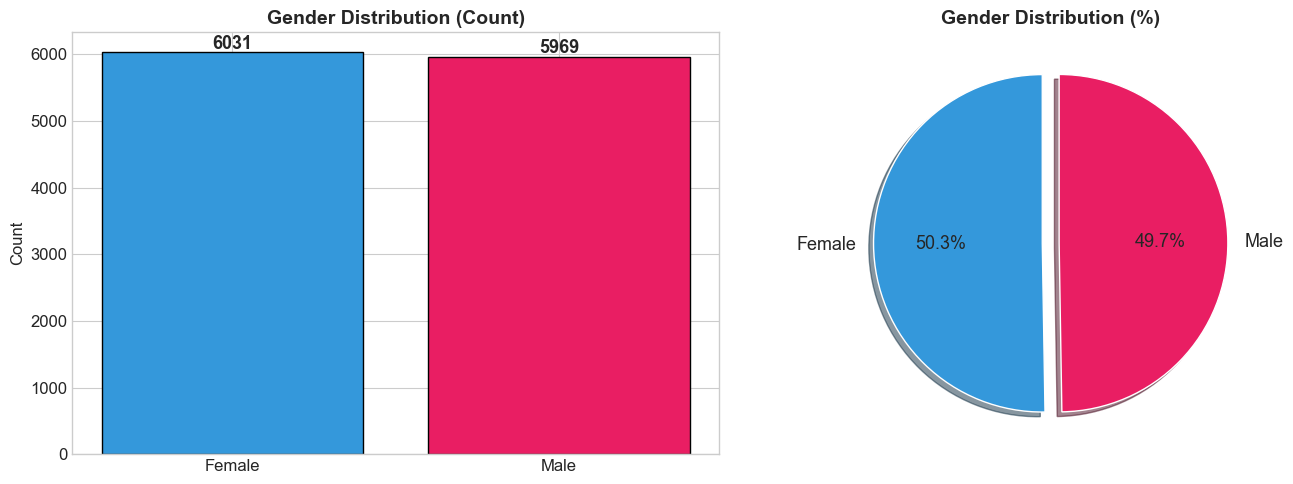

In [23]:
# ============================================================
# GENDER DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
gender_counts = df["Gender"].value_counts()
colors = ["#3498db", "#e91e63"]
axes[0].bar(gender_counts.index, gender_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Gender Distribution (Count)", fontweight="bold")
axes[0].set_ylabel("Count")

for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold", fontsize=13)

# Pie chart
axes[1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True,
    textprops={"fontsize": 13}
)
axes[1].set_title("Gender Distribution (%)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "gender_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

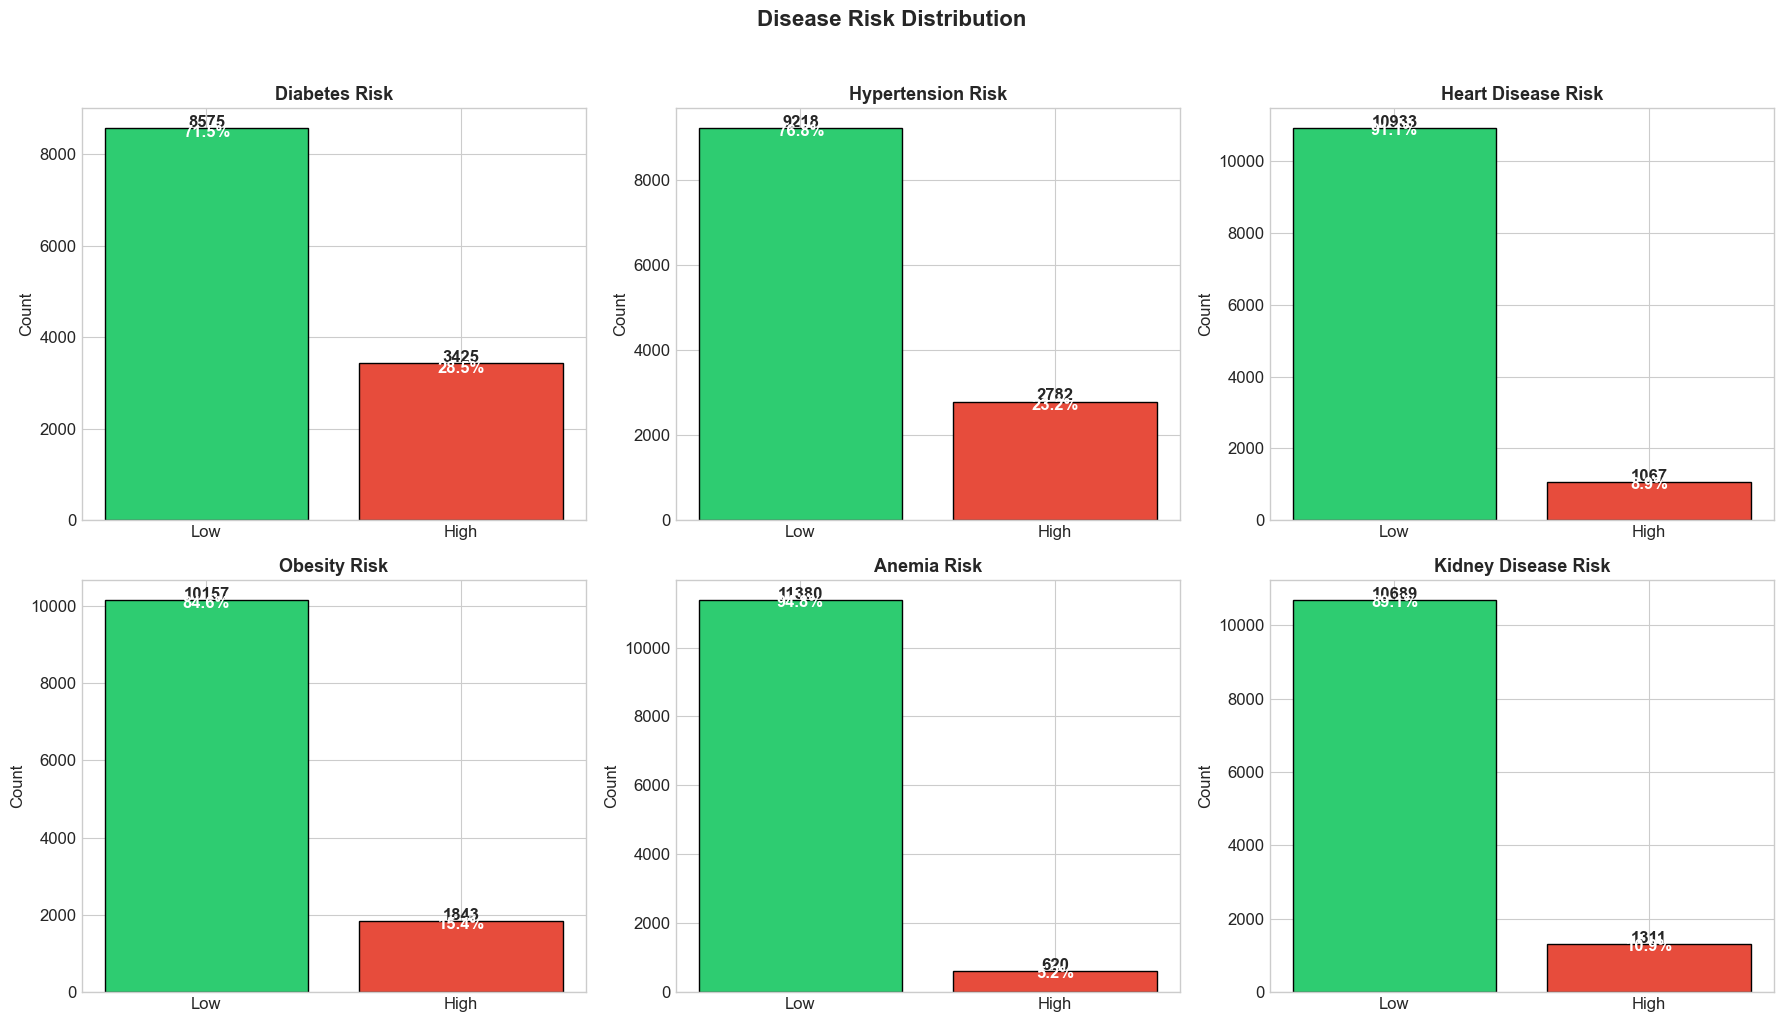

In [24]:
# ============================================================
# DISEASE RISK DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_disease = ["#2ecc71", "#e74c3c"]

for idx, disease in enumerate(DISEASE_COLUMNS):
    counts = df[disease].value_counts()
    axes[idx].bar(counts.index, counts.values, color=colors_disease, edgecolor="black")
    axes[idx].set_title(disease.replace("_", " "), fontweight="bold", fontsize=13)
    axes[idx].set_ylabel("Count")
    axes[idx].set_xticks([0, 1] if counts.index.dtype != object else range(len(counts)))

    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 30, str(v), ha="center", fontweight="bold")

    # Add percentage
    total = counts.sum()
    for i, v in enumerate(counts.values):
        pct = v / total * 100
        axes[idx].text(i, v - 200, f"{pct:.1f}%", ha="center", color="white", fontweight="bold")

plt.suptitle("Disease Risk Distribution", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "disease_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# ============================================================
# CLASS BALANCE CHECK
# ============================================================

print("=" * 60)
print("CLASS BALANCE ANALYSIS")
print("=" * 60)

balance_data = []

for disease in DISEASE_COLUMNS:
    counts = df[disease].value_counts()
    high_count = counts.get("High", counts.get(1, 0))
    low_count = counts.get("Low", counts.get(0, 0))
    total = high_count + low_count
    ratio = high_count / low_count if low_count > 0 else float("inf")

    balance_data.append({
        "Disease": disease,
        "High Risk": high_count,
        "Low Risk": low_count,
        "High %": round(high_count / total * 100, 1),
        "Low %": round(low_count / total * 100, 1),
        "Ratio (H:L)": round(ratio, 2),
        "Balanced": "" if 0.7 <= ratio <= 1.3 else "⚠️"
    })

balance_df = pd.DataFrame(balance_data)
print(balance_df.to_string(index=False))

CLASS BALANCE ANALYSIS
            Disease  High Risk  Low Risk  High %  Low %  Ratio (H:L) Balanced
      Diabetes_Risk       3425      8575    28.5   71.5         0.40       ⚠️
  Hypertension_Risk       2782      9218    23.2   76.8         0.30       ⚠️
 Heart_Disease_Risk       1067     10933     8.9   91.1         0.10       ⚠️
       Obesity_Risk       1843     10157    15.4   84.6         0.18       ⚠️
        Anemia_Risk        620     11380     5.2   94.8         0.05       ⚠️
Kidney_Disease_Risk       1311     10689    10.9   89.1         0.12       ⚠️


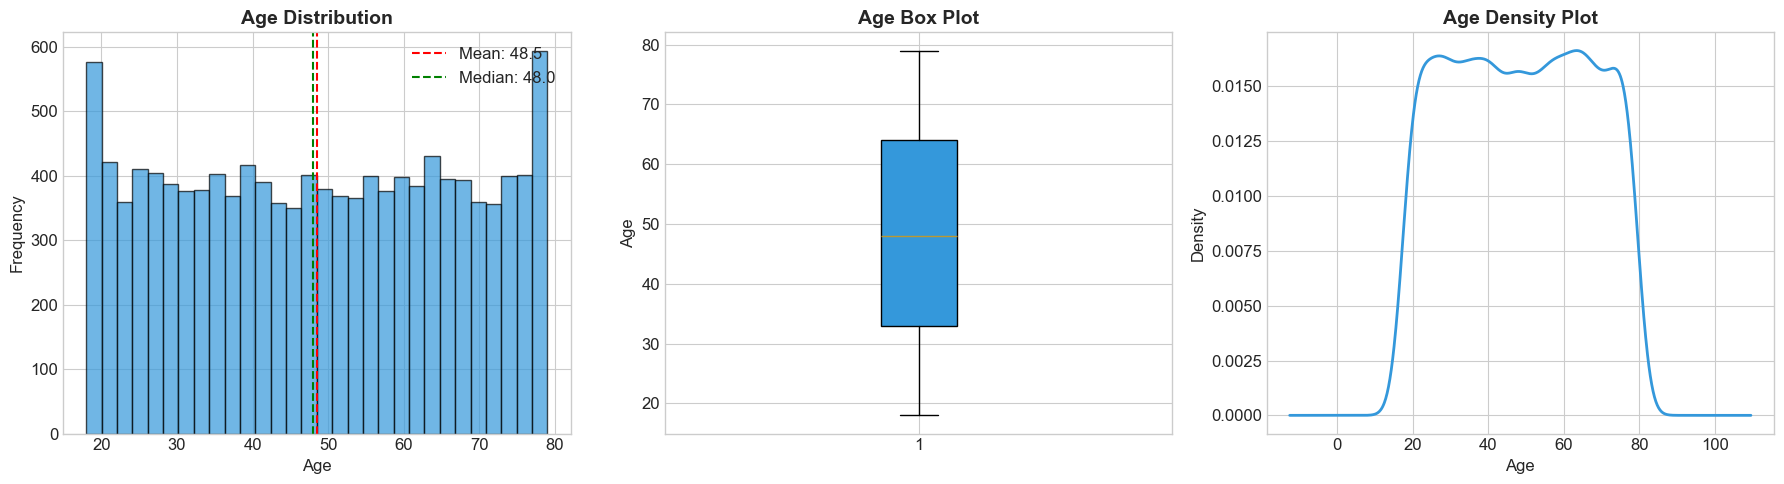


📊 Age Statistics:
   Mean: 48.5
   Median: 48.0
   Std: 18.0
   Range: 18 - 79


In [26]:
# ============================================================
# AGE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df["Age"], bins=30, color="#3498db", edgecolor="black", alpha=0.7)
axes[0].axvline(df["Age"].mean(), color="red", linestyle="--", label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df["Age"].median(), color="green", linestyle="--", label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title("Age Distribution", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot
bp = axes[1].boxplot(df["Age"], patch_artist=True)
bp["boxes"][0].set_facecolor("#3498db")
axes[1].set_title("Age Box Plot", fontweight="bold")
axes[1].set_ylabel("Age")

# KDE plot
df["Age"].plot(kind="kde", ax=axes[2], color="#3498db", linewidth=2)
axes[2].set_title("Age Density Plot", fontweight="bold")
axes[2].set_xlabel("Age")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "age_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n Age Statistics:")
print(f"   Mean: {df['Age'].mean():.1f}")
print(f"   Median: {df['Age'].median():.1f}")
print(f"   Std: {df['Age'].std():.1f}")
print(f"   Range: {df['Age'].min()} - {df['Age'].max()}")

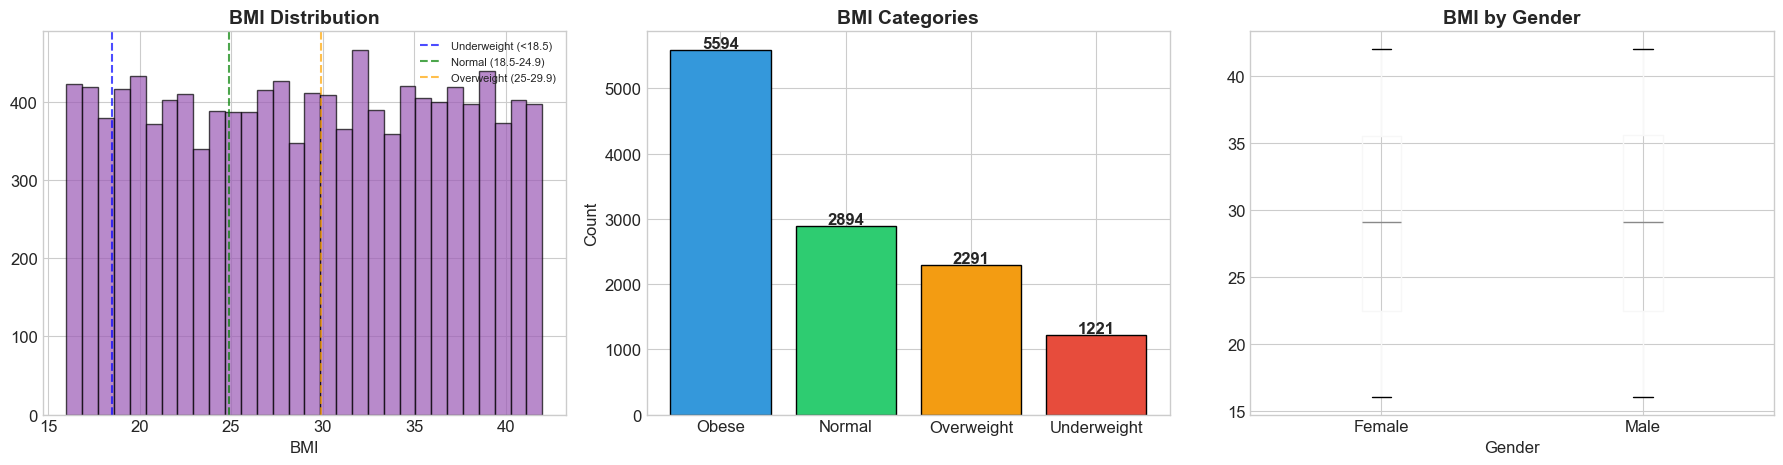

In [27]:
# ============================================================
# BMI DISTRIBUTION & CATEGORIES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram with BMI categories
axes[0].hist(df["BMI"], bins=30, color="#9b59b6", edgecolor="black", alpha=0.7)
axes[0].axvline(18.5, color="blue", linestyle="--", alpha=0.7, label="Underweight (<18.5)")
axes[0].axvline(24.9, color="green", linestyle="--", alpha=0.7, label="Normal (18.5-24.9)")
axes[0].axvline(29.9, color="orange", linestyle="--", alpha=0.7, label="Overweight (25-29.9)")
axes[0].set_title("BMI Distribution", fontweight="bold")
axes[0].set_xlabel("BMI")
axes[0].legend(fontsize=8)

# BMI Categories
bmi_categories = pd.cut(df["BMI"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)
bmi_counts = bmi_categories.value_counts()
colors_bmi = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]
axes[1].bar(bmi_counts.index, bmi_counts.values, color=colors_bmi, edgecolor="black")
axes[1].set_title("BMI Categories", fontweight="bold")
axes[1].set_ylabel("Count")

for i, v in enumerate(bmi_counts.values):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Box plot by gender
if df["Gender"].dtype == object:
    df.boxplot(column="BMI", by="Gender", ax=axes[2])
else:
    gender_map = {0: "Male", 1: "Female"}
    df_temp = df.copy()
    df_temp["Gender_Label"] = df_temp["Gender"].map(gender_map)
    df_temp.boxplot(column="BMI", by="Gender_Label", ax=axes[2])

axes[2].set_title("BMI by Gender", fontweight="bold")
plt.suptitle("")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "bmi_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()